In [1]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

## 1. Initiation

In [2]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus

In [ ]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
padding = 1000
length = end-start + 2*padding
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - padding
locus_end = locus_start + length
#locus_sequence = chromosome[-padding1 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [ ]:
period, amplitude, chem_pot = 10, 0.07, 8

fiber.calc_energy_landscape(period=period, amplitude=amplitude, chemical_potential=chem_pot)

n = 200
average_occ = np.zeros(length)

for i in tqdm(range(n)):
    dyads = fiber.sample_fiber_configuration()
    average_occ += fiber.calc_methylation(dyads, motifs=["AT"], efficiency=0.7).protected
average_occ /= n
footprints = convert_to_footprints([average_occ], fiber.index)



  4%|▍         | 8/200 [00:00<00:02, 79.37it/s]

100%|██████████| 200/200 [00:02<00:00, 69.31it/s]


<Axes: title={'center': 'Predicted vs. measured Segmented Least Squares Fit'}, xlabel='Measured occupancy', ylabel='Predicted occupancy'>

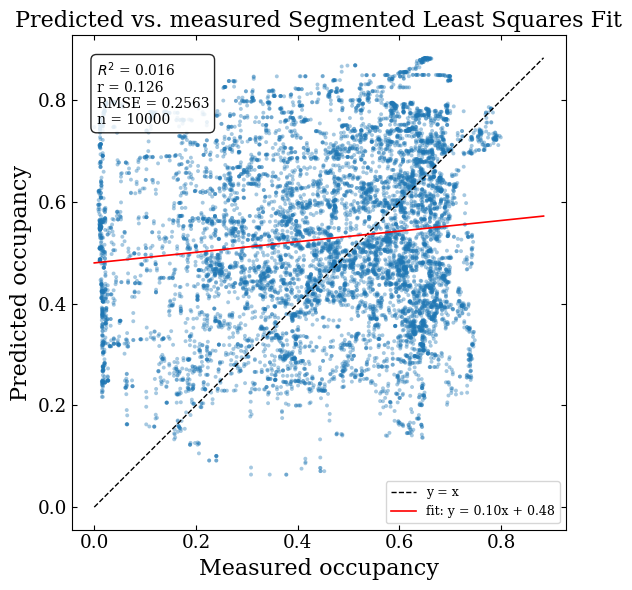

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured occupancy')
    ax.set_ylabel('Predicted occupancy')
    ax.set_title(title or 'Predicted vs. measured Segmented Least Squares Fit')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    return ax

## 2. LSQ-fit function

In [ ]:
import numpy as np
import cma

def apply_ndr_barriers(fiber, barrier_height, ndr_upstream=150, ndr_downstream=50):
    """Add energy penalty at promoter NDR positions derived from ORF annotations."""
    nfr_energy = np.zeros(len(fiber.sequence))
    for orf in fiber.orfs:
        tss = orf['start'] if orf['strand'] == 1 else orf['end']
        local = tss - fiber.index[0]
        if orf['strand'] == 1:
            lo = max(0, local - ndr_upstream)
            hi = min(len(nfr_energy), local + ndr_downstream)
        else:
            lo = max(0, local - ndr_downstream)
            hi = min(len(nfr_energy), local + ndr_upstream)
        nfr_energy[lo:hi] += barrier_height
    fiber.energy += nfr_energy
    fiber.dyad_probability, fiber.occupancy = compute_vanderlick(fiber.energy)

def model_func(n, fiber, period, amplitude, chemical_potential,
               use_ndr_barrier=False, barrier_height=5.0):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    if use_ndr_barrier:
        apply_ndr_barriers(fiber, barrier_height)

    seq_len = len(fiber.sequence)
    average_occ = np.zeros(seq_len)
    for _ in range(n):
        dyads = fiber.sample_fiber_configuration()
        average_occ += fiber.calc_methylation(dyads, motifs=["AT"], efficiency=0.7).protected
    average_occ /= n
    return average_occ[padding:-padding]

def phase_amp_mean_loss_fit(n, fiber, occupancy, model_func, bounds,
                            use_ndr_barrier=False, barrier_height=5.0, x0=None, disp=False):
    y_data = np.asarray(occupancy)
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    call_count = [0]

    def cost(params_norm, disp=disp):
        call_count[0] += 1
        params = lows + np.array(params_norm) * (highs - lows)
        y_pred = model_func(n, fiber, *params,
                            use_ndr_barrier=use_ndr_barrier,
                            barrier_height=barrier_height)

        corr = np.corrcoef(y_pred, y_data)[0, 1]
        phase_loss = 1 - corr
        amp_loss  = ((y_pred.std()  - y_data.std())  / (y_data.std()  + 1e-10)) ** 2
        mean_loss = ((y_pred.mean() - y_data.mean()) / (y_data.mean() + 1e-10)) ** 2

        val = phase_loss + amp_loss + mean_loss
        if call_count[0] % 10 == 0 and disp:
            print(f"  eval {call_count[0]}: cost={val:.4f}, params={np.round(params, 3)}", flush=True)
        return float(val)

    if x0 is None:
        x0_norm = [0.5] * len(bounds)
    else:
        x0_norm = [(x - lo) / (hi - lo) for x, (lo, hi) in zip(x0, bounds)]

    result = cma.fmin(
        cost, x0_norm, sigma0=0.3,
        options={
            'bounds': [[0] * len(bounds), [1] * len(bounds)],
            'maxiter': 300,
            'tolx': 1e-4,
            'tolfun': 1e-4,
            'verbose': -9,
        },
    )

    # print(f"\nDone after {call_count[0]} evaluations")
    return lows + np.array(result[0]) * (highs - lows)

bounds = [
    (9, 11),      # period
    (0.01, 0.18), # amplitude
    (4, 18),      # chemical_potential
]

# --- toggle here ---
USE_NDR_BARRIER = False
BARRIER_HEIGHT  = 5.0   # kT units; higher = stronger NDR exclusion

In [6]:
period_lsq, amplitude_lsq, chemical_potential_lsq = phase_amp_mean_loss_fit(
    20, fiber, occupancy, model_func, bounds,
    use_ndr_barrier=USE_NDR_BARRIER,
    barrier_height=BARRIER_HEIGHT,
)
print(f"period={period_lsq:.3f}, amplitude={amplitude_lsq:.4f}, chemical_potential={chemical_potential_lsq:.3f}")

/home/mvenrooij/NucTool/genomics/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mvenrooij/NucTool/genomics/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  eval 10: cost=1.7824, params=[10.997  0.119 10.525]
  eval 20: cost=1.1955, params=[9.151 0.021 4.175]
  eval 30: cost=1.9625, params=[9.472 0.037 8.246]
  eval 40: cost=1.3511, params=[9.18  0.011 4.897]
  eval 50: cost=1.5595, params=[9.029 0.088 4.186]
  eval 60: cost=1.2120, params=[9.191 0.021 4.432]
  eval 70: cost=1.2244, params=[10.192  0.037  4.244]
  eval 80: cost=1.5200, params=[9.178 0.013 6.061]
  eval 90: cost=1.2763, params=[9.068 0.019 4.628]
  eval 100: cost=0.9120, params=[9.128 0.067 8.006]
  eval 110: cost=1.0858, params=[9.037 0.077 6.291]
  eval 120: cost=1.0432, params=[9.192 0.044 5.879]
  eval 130: cost=1.5071, params=[9.    0.095 7.47 ]
  eval 140: cost=1.2059, params=[9.058 0.052 7.47 ]
  eval 150: cost=1.1315, params=[9.671 0.079 8.882]
  eval 160: cost=1.0566, params=[9.565 0.062 8.658]
  eval 170: cost=0.9049, params=[9.45  0.056 6.622]
  eval 180: cost=1.1637, params=[9.134 0.036 4.038]
  eval 190: cost=1.0631, params=[9.535 0.057 6.825]
  eval 200: cos

In [7]:
fiber.calc_energy_landscape(period=period_lsq, amplitude=amplitude_lsq, chemical_potential=chemical_potential_lsq)
if USE_NDR_BARRIER:
    apply_ndr_barriers(fiber, BARRIER_HEIGHT)

n = 200
average_occ = np.zeros(length)

for i in tqdm(range(n)):
    dyads = fiber.sample_fiber_configuration()
    average_occ += fiber.calc_methylation(dyads, motifs=["AT"], efficiency=0.7).protected
average_occ /= n
footprints = convert_to_footprints([average_occ], fiber.index)


100%|██████████| 200/200 [00:03<00:00, 65.53it/s]


Text(0, 0.5, 'Methylation Probability')

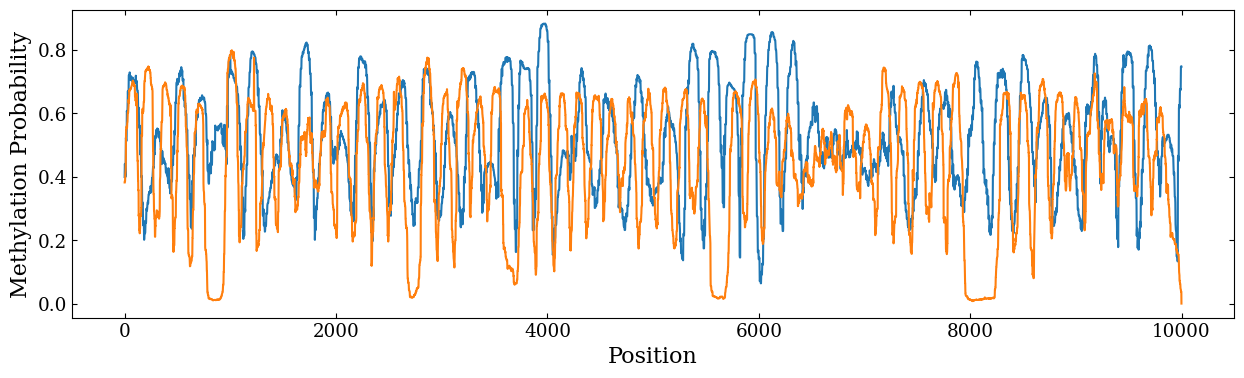

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
# plt.plot(result.methylated[padding:11000], label='Methylation Probability', marker='x', linestyle='', markersize=5)
plt.plot(average_occ[padding:-padding], label='Protected Probability')
plt.plot(occupancy, label='Occupancy')
# plt.plot(footprints, label='Footprints')
plt.xlabel('Position')
plt.ylabel('Methylation Probability')

plot_correlation(occupancy, average_occ[padding:-padding])

## 3. Phase-fit

In [10]:
import numpy as np
import cma
from scipy.signal import find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.fft import rfft


# ── Metrics ───────────────────────────────────────────────────────────────────

def frfsm(H_A, H_B, sigma_0_db=6.0):
    eps = np.abs(
        10 * np.log10(np.abs(H_A) ** 2 + 1e-20)
        - 10 * np.log10(np.abs(H_B) ** 2 + 1e-20)
    )
    return np.exp(-0.5 * (eps / sigma_0_db) ** 2)


def psm(H_A, H_B, sigma_0_rad=np.pi / 4):
    phase_e = np.unwrap(np.angle(H_A)) - np.unwrap(np.angle(H_B))
    phase_w = np.abs(((phase_e + np.pi) % (2 * np.pi)) - np.pi)
    return np.exp(-0.5 * (phase_w / sigma_0_rad) ** 2)


# ── LFS internals ─────────────────────────────────────────────────────────────

def _find_peaks(arr, min_distance=5):
    idx, _ = find_peaks(arr, distance=min_distance)
    idx = idx[np.argsort(arr[idx])[::-1]]
    return np.sort(idx)


def _lfs_segment(x_log, seg_baseline, seg_comparison, n_interp=1000):
    f_interp = np.linspace(x_log[0], x_log[-1], n_interp)
    interp_b = interp1d(x_log, seg_baseline,   kind='linear', bounds_error=False, fill_value=0.0)
    interp_c = interp1d(x_log, seg_comparison, kind='linear', bounds_error=False, fill_value=0.0)
    b_uniform = interp_b(f_interp)
    c_uniform = interp_c(f_interp)

    corr  = correlate(b_uniform, c_uniform, mode='full')
    lags  = np.arange(-(n_interp - 1), n_interp)
    best  = lags[np.argmax(corr)]
    shift = best * (f_interp[1] - f_interp[0])

    interp_shifted = interp1d(x_log + shift, seg_comparison, kind='linear',
                              bounds_error=False, fill_value=np.nan)
    return interp_shifted(x_log), np.exp(shift)


def _apply_lfs(x, baseline, comparison, min_peak_distance=5, overlap_fraction=0.20):
    x          = np.asarray(x,          dtype=float)
    baseline   = np.asarray(baseline,   dtype=float)
    comparison = np.asarray(comparison, dtype=float)
    N      = len(x)
    x_log  = np.log(np.clip(x, 1e-30, None))

    peaks = _find_peaks(baseline, min_distance=min_peak_distance)
    if len(peaks) == 0:
        return comparison.copy(), [1.0], [0, N]

    edges = [0] + [(peaks[i] + peaks[i+1]) // 2
                   for i in range(len(peaks) - 1)] + [N]

    out    = np.full(N, np.nan)
    counts = np.zeros(N)
    taus   = []

    for start, end in zip(edges[:-1], edges[1:]):
        pad     = max(1, int((end - start) * overlap_fraction))
        i_start = max(0, start - pad)
        i_end   = min(N, end   + pad)
        seg_x   = x_log[i_start:i_end]

        if len(seg_x) < 3:
            taus.append(1.0)
            out[i_start:i_end] = comparison[i_start:i_end]
            counts[i_start:i_end] += 1
            continue

        shifted, tau = _lfs_segment(seg_x, baseline[i_start:i_end],
                                           comparison[i_start:i_end])
        taus.append(tau)
        valid = ~np.isnan(shifted)
        out[i_start:i_end][valid]    += shifted[valid]
        counts[i_start:i_end][valid] += 1

    mask = counts > 0
    out[mask] /= counts[mask]
    out[np.isnan(out)] = comparison[np.isnan(out)]
    return out, taus, edges


def _shift_phase(x, phase, taus, edges):
    x_log = np.log(np.clip(np.asarray(x, dtype=float), 1e-30, None))
    out   = np.copy(phase).astype(float)
    for i, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
        if i >= len(taus):
            break
        shifted_log = x_log[start:end] + np.log(taus[i])
        fn = interp1d(shifted_log, phase[start:end], kind='linear',
                      bounds_error=False, fill_value=np.nan)
        shifted_ph = fn(x_log[start:end])
        valid = ~np.isnan(shifted_ph)
        out[start:end][valid] = shifted_ph[valid]
    return out


# ── Fitting function ──────────────────────────────────────────────────────────

def complex_spectral_fit_frfsm_psm(
    n,
    fiber,
    y_data,
    model_func,
    bounds,
    alpha=0.5,
    sigma_db=6.0,
    sigma_rad=np.pi / 4,
    freq_range=(5, 150),
    use_ndr_barrier=False,
    barrier_height=5.0,
):
    window    = np.hanning(len(y_data))
    H_obs     = rfft(y_data * window)[freq_range[0]:freq_range[1]]
    mag_obs   = np.clip(np.abs(H_obs), 1e-10, None)
    phase_obs = np.angle(H_obs)
    f_axis    = np.arange(freq_range[0], freq_range[1], dtype=float) + 1.0

    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    call_count = [0]

    def objective(params_norm):
        call_count[0] += 1
        params = lows + np.array(params_norm) * (highs - lows)
        try:
            model_sig = model_func(n, fiber, *params,
                                   use_ndr_barrier=use_ndr_barrier,
                                   barrier_height=barrier_height)
            H_mod     = rfft(model_sig * window)[freq_range[0]:freq_range[1]]
            mag_mod   = np.clip(np.abs(H_mod), 1e-10, None)
            phase_mod = np.angle(H_mod)

            mag_lfs, taus, edges = _apply_lfs(f_axis, mag_obs, mag_mod)
            mag_lfs              = np.clip(mag_lfs, 1e-10, None)
            phase_lfs            = _shift_phase(f_axis, phase_mod, taus, edges)

            amp_score   = float(np.mean(frfsm(mag_obs, mag_lfs,   sigma_db)))
            phase_score = float(np.mean(psm  (phase_obs, phase_lfs, sigma_rad)))
            cost = -(alpha * amp_score + (1 - alpha) * phase_score)
        except Exception:
            cost = 0.0  # worst score on failure

        if call_count[0] % 10 == 0:
            params_disp = np.round(lows + np.array(params_norm) * (highs - lows), 3)
            print(f"  eval {call_count[0]}: cost={cost:.4f}, params={params_disp}", flush=True)
        return float(cost)

    x0_norm = [0.5] * len(bounds)
    result = cma.fmin(
        objective, x0_norm, sigma0=0.3,
        options={
            'bounds': [[0] * len(bounds), [1] * len(bounds)],
            'maxiter': 300,
            'tolx': 1e-4,
            'tolfun': 1e-4,
            'verbose': -9,
        },
    )

    print(f"\nDone after {call_count[0]} evaluations")
    return lows + np.array(result[0]) * (highs - lows)


# ── Call ──────────────────────────────────────────────────────────────────────

bounds_fp = [
    (9.5, 11.0),
    (0.01, 0.19),
    (0, 50),
]

period_fp, amplitude_fp, chemical_potential_fp = complex_spectral_fit_frfsm_psm(
    20, fiber, occupancy, model_func, bounds_fp,
    alpha=0.1,
    use_ndr_barrier=USE_NDR_BARRIER,
    barrier_height=BARRIER_HEIGHT,
)
print(f"period={period_fp:.4f}, amplitude={amplitude_fp:.4f}, mu={chemical_potential_fp:.4f}")

  eval 10: cost=-0.4533, params=[10.371  0.064 34.669]
  eval 20: cost=-0.4533, params=[ 9.751  0.053 28.65 ]
  eval 30: cost=-0.4533, params=[10.453  0.03  23.239]
  eval 40: cost=-0.4639, params=[9.565 0.099 9.694]
  eval 50: cost=-0.5009, params=[9.675 0.011 5.809]
  eval 60: cost=-0.4553, params=[9.616 0.029 0.657]
  eval 70: cost=-0.5386, params=[10.118  0.093  2.397]
  eval 80: cost=-0.4533, params=[9.5170e+00 1.0000e-02 1.3512e+01]
  eval 90: cost=-0.5700, params=[9.928 0.112 1.188]
  eval 100: cost=-0.5243, params=[10.392  0.047  4.795]
  eval 110: cost=-0.4912, params=[9.582 0.094 6.668]
  eval 120: cost=-0.5518, params=[10.042  0.127  5.478]
  eval 130: cost=-0.4533, params=[ 9.525  0.014 12.958]
  eval 140: cost=-0.4533, params=[9.9870e+00 1.2000e-02 2.6718e+01]
  eval 150: cost=-0.4914, params=[ 9.816  0.132 11.71 ]
  eval 160: cost=-0.5568, params=[10.262  0.168  2.131]
  eval 170: cost=-0.5243, params=[10.581  0.132 12.003]
  eval 180: cost=-0.5145, params=[10.444  0.153 

KeyboardInterrupt: 

100%|██████████| 200/200 [00:01<00:00, 108.45it/s]


<Axes: title={'center': 'Predicted vs. measured Segmented Least Squares Fit'}, xlabel='Measured occupancy', ylabel='Predicted occupancy'>

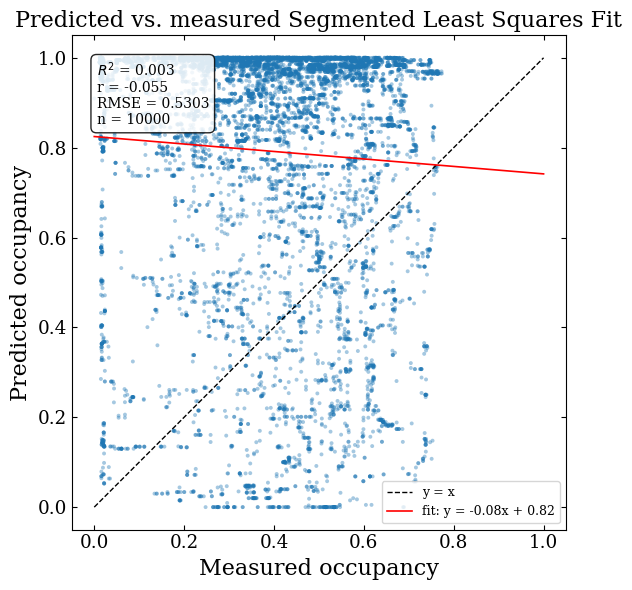

In [ ]:
fiber.calc_energy_landscape(period=period_fp, amplitude=amplitude_fp, chemical_potential=chemical_potential_fp)
if USE_NDR_BARRIER:
    apply_ndr_barriers(fiber, BARRIER_HEIGHT)

n = 200
average_occ = np.zeros(length)

for i in tqdm(range(n)):
    dyads = fiber.sample_fiber_configuration()
    average_occ += fiber.calc_methylation(dyads, motifs=["AT"], efficiency=0.7).protected
average_occ /= n
footprints = convert_to_footprints([average_occ], fiber.index)

plot_correlation(occupancy, average_occ[padding:-padding])

Text(0, 0.5, 'Methylation Probability')

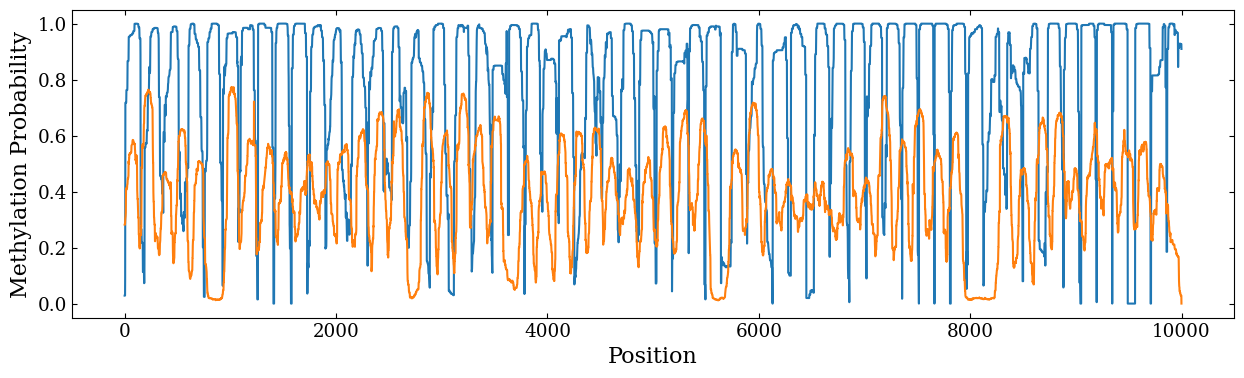

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
# plt.plot(result.methylated[1000:11000], label='Methylation Probability', marker='x', linestyle='', markersize=5)
plt.plot(average_occ[padding:-padding], label='Protected Probability')
plt.plot(occupancy, label='Occupancy')
# plt.plot(footprints, label='Footprints')
plt.xlabel('Position')
plt.ylabel('Methylation Probability')

## 4. Segmented lsq fit

In [ ]:
segment_length  = 400
seg_model_len   = segment_length + 2000   # 1000 bp padding each side
n_segments      = (end - start) // segment_length

seg_var_dic = {
    'period':             np.zeros(n_segments),
    'amplitude':          np.zeros(n_segments),
    'chemical_potential': np.zeros(n_segments),
}

seg_bounds = [
    (9, 11),      # period
    (0.01, 0.18), # amplitude
    (4, 18),      # chemical_potential
]

for k in tqdm(range(n_segments)):
    seg_start    = locus_start + k * segment_length
    seg_end      = min(seg_start + seg_model_len, locus_end + padding)
    seg_sequence = chromosome[seg_start:seg_end]

    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    seg_fiber.fetch_orfs_by_range(start=seg_start, end=seg_end, chromosome=chrom_number)

    seg_occupancy = occupancy[k * segment_length : (k + 1) * segment_length]

    p, a, mu = phase_amp_mean_loss_fit(
        20, seg_fiber, seg_occupancy, model_func, seg_bounds,
        use_ndr_barrier=USE_NDR_BARRIER,
        barrier_height=BARRIER_HEIGHT,
    )
    seg_var_dic['period'][k]             = p
    seg_var_dic['amplitude'][k]          = a
    seg_var_dic['chemical_potential'][k] = mu


  eval 10: cost=2.7826, params=[9.708 0.011 8.169]
  eval 20: cost=1.8227, params=[9.803 0.033 7.797]
  eval 30: cost=0.6582, params=[10.214  0.089  4.673]
  eval 40: cost=0.5296, params=[10.459  0.107  6.361]
  eval 50: cost=0.6174, params=[10.147  0.086  7.449]
  eval 60: cost=1.0917, params=[10.675  0.117  8.296]
  eval 70: cost=1.3483, params=[9.695 0.093 9.052]
  eval 80: cost=2.4567, params=[10.283  0.073 12.188]
  eval 90: cost=1.2979, params=[9.629 0.058 9.147]
  eval 100: cost=0.8818, params=[10.411  0.081  9.442]
  eval 110: cost=0.8756, params=[10.336  0.091  7.333]
  eval 120: cost=0.6408, params=[ 9.976  0.105 10.612]
  eval 130: cost=0.4438, params=[ 9.97   0.102 12.075]
  eval 140: cost=0.8753, params=[ 9.852  0.111 13.234]
  eval 150: cost=0.5562, params=[10.074  0.086  7.951]
  eval 160: cost=0.7177, params=[10.251  0.088  7.469]
  eval 170: cost=0.5698, params=[10.189  0.065  4.124]
  eval 180: cost=0.5434, params=[ 9.966  0.092 10.216]
  eval 190: cost=0.4535, params

/home/mvenrooij/NucTool/genomics/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mvenrooij/NucTool/genomics/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  eval 10: cost=1.6232, params=[9.99  0.034 5.896]
  eval 20: cost=1.6408, params=[10.318  0.07   5.253]
  eval 30: cost=1.3263, params=[9.615 0.042 6.683]
  eval 40: cost=1.4294, params=[10.289  0.05   4.335]
  eval 50: cost=1.3326, params=[9.208 0.071 5.39 ]
  eval 60: cost=0.8500, params=[9.711 0.049 5.327]
  eval 70: cost=1.4005, params=[9.895 0.089 5.568]
  eval 80: cost=1.1294, params=[ 9.184  0.086 10.719]
  eval 90: cost=0.8430, params=[ 9.321  0.081 10.393]
  eval 100: cost=0.5403, params=[9.381 0.08  9.836]
  eval 110: cost=1.0130, params=[9.663 0.049 5.958]
  eval 120: cost=0.7965, params=[ 9.387  0.076 10.452]
  eval 130: cost=0.9272, params=[ 9.461  0.097 11.241]
  eval 140: cost=0.5089, params=[9.558 0.066 8.67 ]
  eval 150: cost=0.8300, params=[9.428 0.067 8.739]
  eval 160: cost=0.5187, params=[ 9.488  0.079 10.38 ]
  eval 170: cost=0.4950, params=[ 9.505  0.083 10.795]
  eval 180: cost=0.5950, params=[9.468 0.08  9.969]
  eval 190: cost=0.5481, params=[ 9.592  0.102 14

IndexError: list index out of range

  0%|          | 0/25 [00:00<?, ?it/s]

 76%|███████▌  | 19/25 [00:17<00:05,  1.14it/s]/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:224: RuntimeWarning: divide by zero encountered in divide
  x = np.arange(w, dtype=np.int32) - w // 2
/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:224: RuntimeWarning: invalid value encountered in divide
  x = np.arange(w, dtype=np.int32) - w // 2
/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:224: RuntimeWarning: invalid value encountered in cos
  x = np.arange(w, dtype=np.int32) - w // 2
/home/mvenrooij/NucTool/nuctool/ChromatinFibers.py:399: RuntimeWarning: All-NaN slice encountered
  free_energy = wrapping_energy
100%|██████████| 25/25 [00:17<00:00,  1.40it/s]


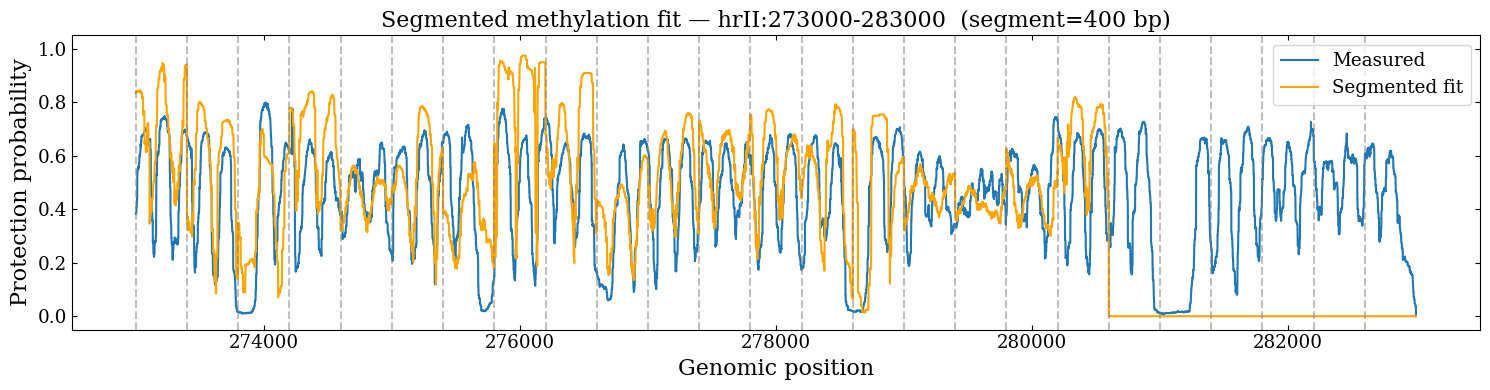

In [12]:
import matplotlib.pyplot as plt

# Reconstruct full signal from per-segment fitted parameters (n=200 for stability)
seg_distribution = []

for k in tqdm(range(n_segments)):
    seg_start    = locus_start + k * segment_length
    seg_end      = min(seg_start + seg_model_len, locus_end + 1000)
    seg_sequence = chromosome[seg_start:seg_end]

    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    if USE_NDR_BARRIER:
        seg_fiber.fetch_orfs_by_range(start=seg_start, end=seg_end, chromosome=chrom_number)

    pred = model_func(
        200, seg_fiber,
        seg_var_dic['period'][k],
        seg_var_dic['amplitude'][k],
        seg_var_dic['chemical_potential'][k],
        use_ndr_barrier=USE_NDR_BARRIER,
        barrier_height=BARRIER_HEIGHT,
    )
    seg_distribution.extend(pred[:segment_length])

seg_distribution = np.array(seg_distribution)
x_coords = np.arange(start, start + len(seg_distribution))

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(x_coords, occupancy[:len(seg_distribution)], label='Measured')
ax.plot(x_coords, seg_distribution, label='Segmented fit', color='orange')
ax.vlines(x_coords[::segment_length], ymin=-0.05, ymax=1.05, color='gray', linestyle='--', alpha=0.5, label='Segment boundaries' if k == 0 else None)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Genomic position')
ax.set_ylabel('Protection probability')
ax.set_title(f'Segmented methylation fit — {chrom}:{start}-{end}  (segment={segment_length} bp)')
ax.legend()
plt.tight_layout()
plt.show()




<Axes: title={'center': 'Segmented fit: predicted vs measured'}, xlabel='Measured occupancy', ylabel='Predicted occupancy'>

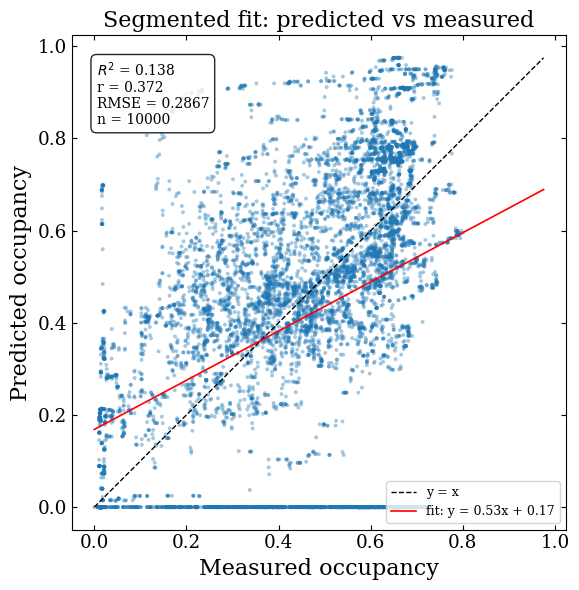

In [13]:
plot_correlation(occupancy[:len(seg_distribution)], seg_distribution,
                 title='Segmented fit: predicted vs measured')

(0.0, 25.0)

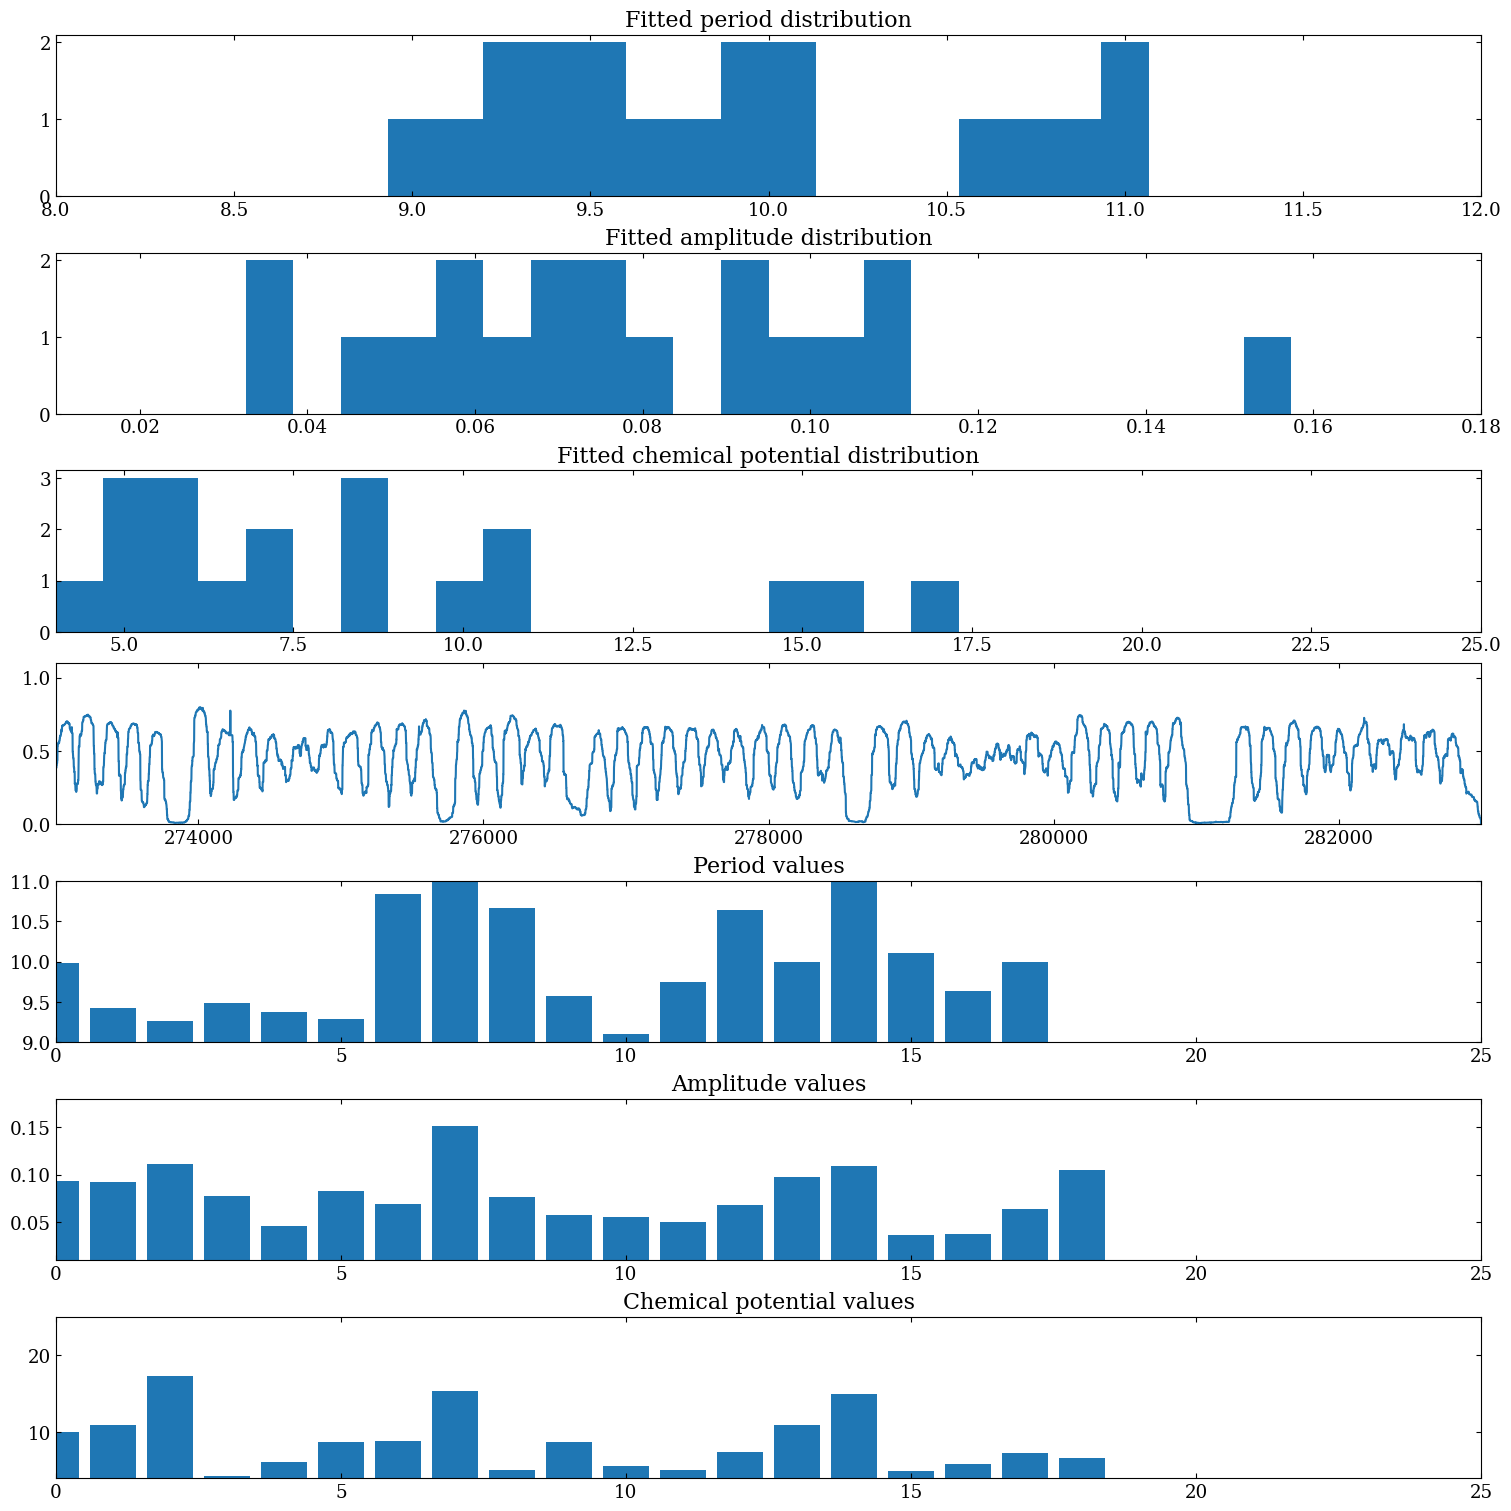

In [31]:
x = np.arange(len(seg_var_dic['period']))

plot = Plotter(fig_size=(15, 15))
plot.new(nrows=7)
ax1, ax2, ax3, ax0, ax4, ax5, ax6 = plot.panels

ax0.plot(x_coords, occupancy[:len(seg_distribution)], label='Measured occupancy')
ax0.set_xlim(start, end)
ax0.set_ylim(0, 1.1)

ax1.hist(seg_var_dic['period'], bins=30, range=(8, 12))
ax1.set_title('Fitted period distribution')
ax1.set_xlim(8, 12)
ax2.hist(seg_var_dic['amplitude'], bins=30, range=(0.01, 0.18))
ax2.set_title('Fitted amplitude distribution')
ax2.set_xlim(0.01, 0.18)
ax3.hist(seg_var_dic['chemical_potential'], bins=30, range=(4, 25))
ax3.set_title('Fitted chemical potential distribution')
ax3.set_xlim(4, 25)
ax4.bar(x, seg_var_dic['period'])
ax4.set_title('Period values')
ax4.set_ylim(9, 11)
ax4.set_xlim(0, 25)
ax5.bar(x, seg_var_dic['amplitude'])
ax5.set_title('Amplitude values')
ax5.set_ylim(0.01, 0.18)
ax5.set_xlim(0, 25)
ax6.bar(x, seg_var_dic['chemical_potential'])
ax6.set_title('Chemical potential values')
ax6.set_ylim(4, 25)
ax6.set_xlim(0, 25)


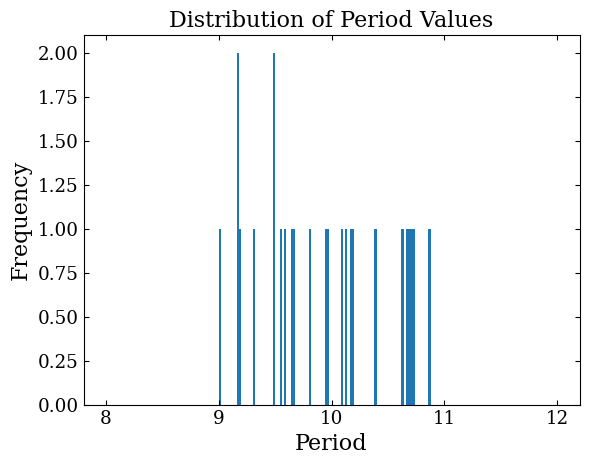

In [ ]:
plt.hist(seg_var_dic['period'], bins=200, range=(8, 12))
plt.xlabel("Period")
plt.ylabel("Frequency")
plt.title("Distribution of Period Values")
plt.show()

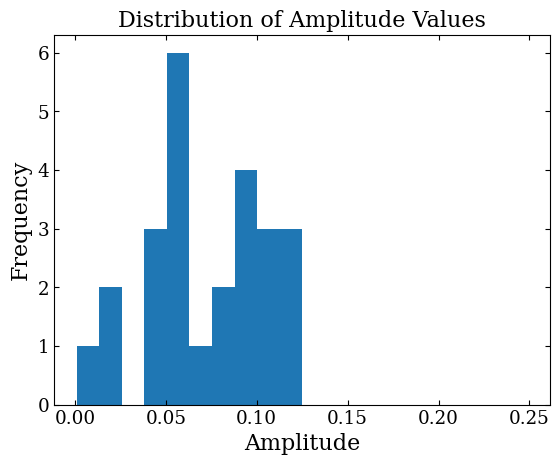

In [ ]:
plt.hist(seg_var_dic['amplitude'], bins=20, range=(0.001, 0.249))
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.title("Distribution of Amplitude Values")
plt.show()

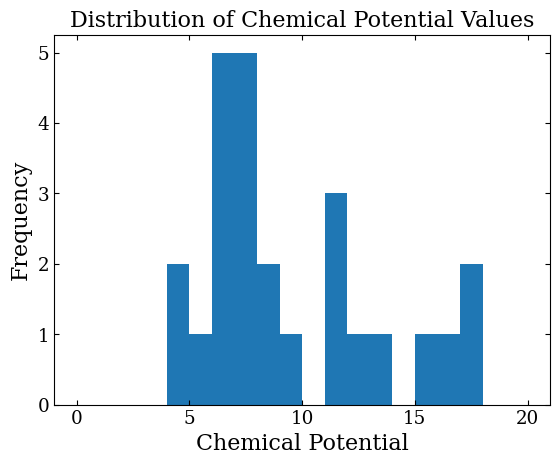

In [ ]:
plt.hist(seg_var_dic['chemical_potential'], bins=20, range=(0, 20))
plt.xlabel("Chemical Potential")
plt.ylabel("Frequency")
plt.title("Distribution of Chemical Potential Values")
plt.show()

In [ ]:
plt.scatter(seg_var_dic['period'], seg_var_dic['amplitude'])
plt.ylim(0, 0.25)
plt.xlim(9, 11)
plt.xlabel("Period")
plt.ylabel("Amplitude")
plt.title("Period vs Amplitude")
plt.show()

NameError: name 'plt' is not defined